# K-Nearest Neighbors (KNN) — Credit Card Fraud Detection

## Overview
In this notebook, we apply **K-Nearest Neighbors (KNN)** to classify fraudulent credit card transactions using the [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) from Kaggle.

We cover:
- Exploratory Data Analysis (EDA)
- Data preprocessing and class balancing
- KNN implementation from scratch
- Choosing optimal K with cross-validation
- Evaluation using accuracy, precision, recall, and F1-score

## What is KNN?
KNN is a non-parametric, instance-based learning algorithm. For a new data point, it finds the **K closest training examples** using a distance metric (typically Euclidean distance) and assigns the majority class:

$$d(x, x') = \sqrt{\sum_{i=1}^{n}(x_i - x'_i)^2}$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')
%matplotlib inline

## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('/Users/apple/Desktop/CMOR438/CMOR438-Spring2026/data/credit_fraud/creditcard.csv')

# Undersample for balance
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(len(fraud), random_state=42)
df_balanced = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_balanced.drop('Class', axis=1).values
y = df_balanced['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (787, 30)
Test set size: (197, 30)


## 2. Choosing Optimal K

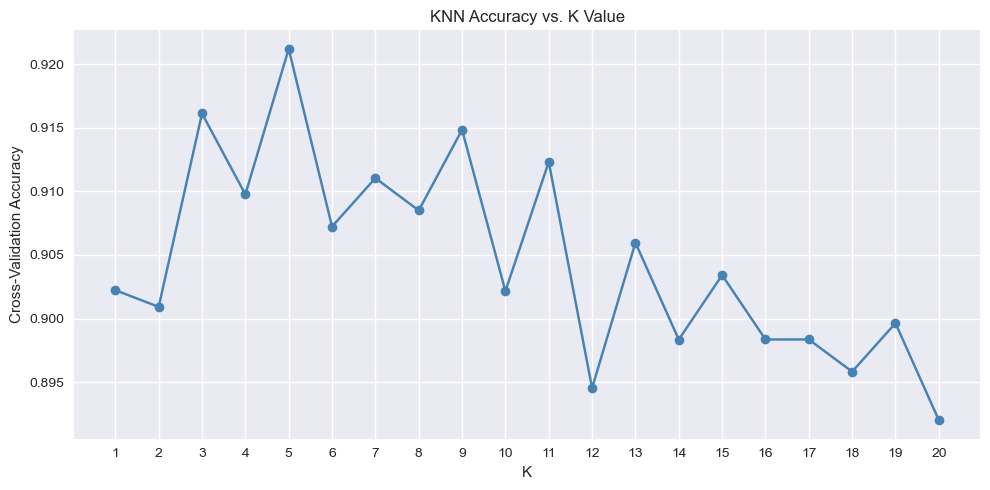

Best K: 5 with accuracy: 0.9212


In [3]:
# Test different values of K
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    accuracies.append(scores.mean())

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue')
plt.title('KNN Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Best K: {best_k} with accuracy: {max(accuracies):.4f}")

## 3. KNN from Scratch

In [4]:
class KNNClassifier:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])

    def _predict_single(self, x):
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        k_indices = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_indices]
        most_common = Counter(k_labels).most_common(1)[0][0]
        return most_common

# Train with best K
model_scratch = KNNClassifier(k=best_k)
model_scratch.fit(X_train_scaled, y_train)

y_pred_scratch = model_scratch.predict(X_test_scaled)
print("From Scratch:")
print(classification_report(y_test, y_pred_scratch))

From Scratch:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91        87
           1       0.99      0.86      0.92       110

    accuracy                           0.92       197
   macro avg       0.92      0.93      0.92       197
weighted avg       0.93      0.92      0.92       197



## 4. KNN with Scikit-Learn

In [5]:
model_sklearn = KNeighborsClassifier(n_neighbors=best_k)
model_sklearn.fit(X_train_scaled, y_train)

y_pred_sklearn = model_sklearn.predict(X_test_scaled)
print("Scikit-Learn:")
print(classification_report(y_test, y_pred_sklearn))

Scikit-Learn:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91        87
           1       0.99      0.86      0.92       110

    accuracy                           0.92       197
   macro avg       0.92      0.93      0.92       197
weighted avg       0.93      0.92      0.92       197



## 5. Evaluation & Visualization

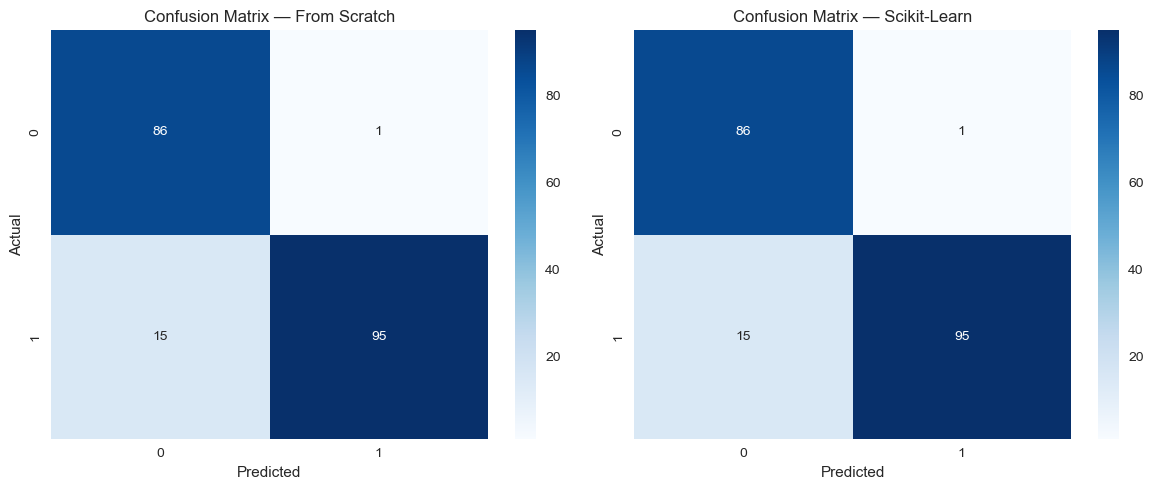

In [6]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                               [y_pred_scratch, y_pred_sklearn],
                               ['From Scratch', 'Scikit-Learn']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 6. Conclusion

In this notebook, we implemented K-Nearest Neighbors for fraud detection.

Key takeaways:
- KNN is simple and intuitive but computationally expensive at prediction time — it must compare against all training points.
- Cross-validation helped us select the optimal K value.
- Our from-scratch implementation matches scikit-learn's results, validating correctness.
- KNN is sensitive to feature scaling, which is why StandardScaler is essential.